# **Introduction to EEG Processing with MNE-Python**



Welcome! This tutorial will guide you through a complete EEG processing pipeline.
 We'll use real EEG data from the MNE sample dataset to learn:
 - How to load and visualize EEG data
 - How to filter out noise
 - How to detect and remove artifacts (eye blinks, heartbeats)
 - How to prepare data for analysis

 **What is EEG?** EEG (Electroencephalography) records electrical activity from your brain
 using sensors (electrodes) placed on the scalp.
 
 These signals are tiny (microvolts!)
 and often contaminated by noise from eye movements, muscle activity, and electronics.

In [21]:
# Import the libraries we need
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Configure display settings
%matplotlib inline
mne.set_log_level('WARNING')  # Reduce verbose output
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## **Step 1:** Load Sample EEG Data

MNE comes with sample data we can practice with. This is real EEG data from a person doing a simple visual/auditory task.

In [22]:
# Download and load the sample dataset (this happens automatically)
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = os.path.join(sample_data_folder, 'MEG', 'sample',
                                     'sample_audvis_raw.fif')

In [23]:
# Load the raw data
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)

In [24]:
# Let's see what we have
print(f"\n📊 Dataset Information:")
print(f"   - Recording duration: {raw.times[-1]:.1f} seconds")
print(f"   - Sampling rate: {raw.info['sfreq']} Hz")
print(f"   - Number of EEG channels: {len(mne.pick_types(raw.info, meg=False, eeg=True))}")
print(f"   - Total channels: {len(raw.ch_names)}")


📊 Dataset Information:
   - Recording duration: 277.7 seconds
   - Sampling rate: 600.614990234375 Hz
   - Number of EEG channels: 59
   - Total channels: 376


In [25]:
raw.info

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

## **Step 2:** Select and Visualize EEG Channels

The sample dataset contains both MEG and EEG. We'll focus only on EEG channels.

In [26]:
# Pick only EEG channels (we'll ignore MEG for this tutorial)
raw = raw.pick(['eeg', 'eog', 'stim'])  # EEG + eye channels + stimulus markers

print(f"\n✅ Selected {len(raw.ch_names)} channels:")
print(f"   - EEG channels: {len(mne.pick_types(raw.info, meg=False, eeg=True))}")
print(f"   - EOG channels (for eye movement): {len(mne.pick_types(raw.info, meg=False, eog=True))}")


✅ Selected 70 channels:
   - EEG channels: 59
   - EOG channels (for eye movement): 1


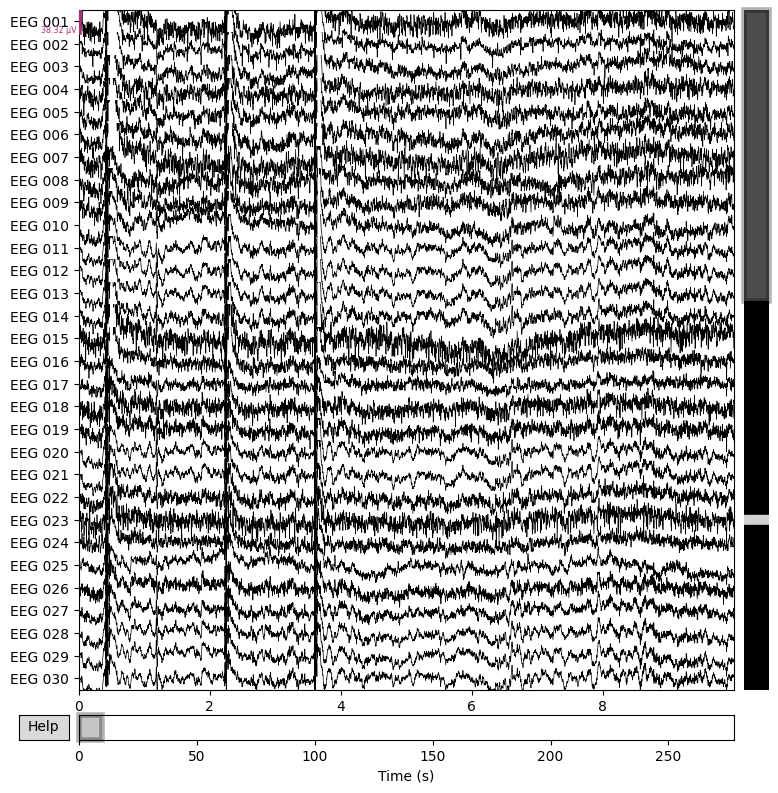

In [27]:
# Quick visualization of the raw data
raw.plot(duration=10, n_channels=30, scalings='auto', title='Raw EEG Data (10 seconds)')
plt.show()

## **Step 4:** Understand the Power Spectrum


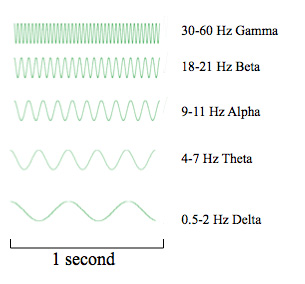

C:\Users\yucca\AppData\Roaming\Python\Python313\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\yucca\AppData\Local\Temp\ipykernel_5892\3166746893.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


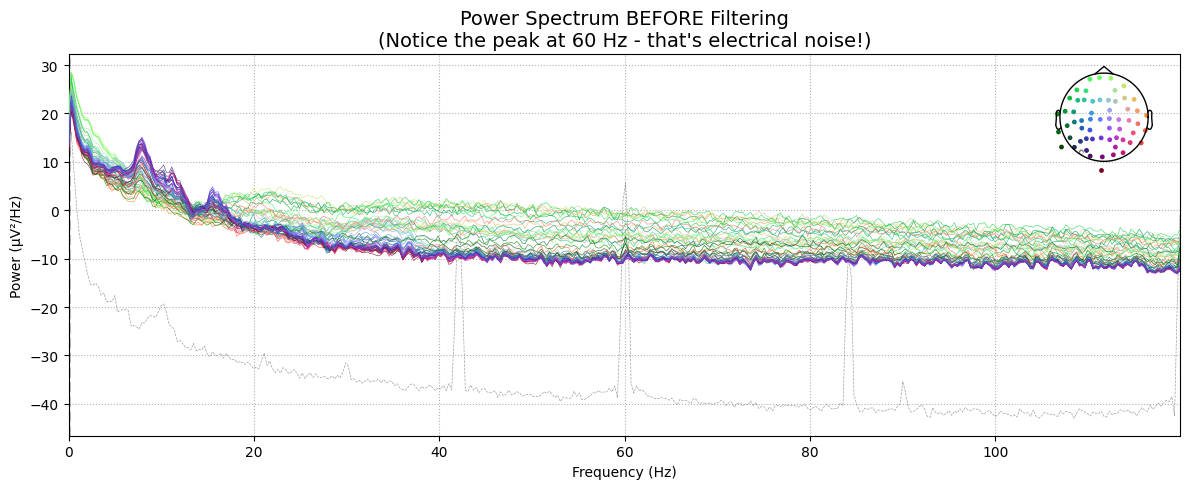

In [28]:
# Compute Power Spectral Density (PSD) - shows which frequencies are strong
fig, ax = plt.subplots(figsize=(12, 5))
raw.compute_psd(fmax=120, picks='eeg').plot(axes=ax)
ax.set_title('Power Spectrum BEFORE Filtering\n(Notice the peak at 60 Hz - that\'s electrical noise!)', 
             fontsize=14)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (µV²/Hz)')
plt.tight_layout()
plt.show()

 
#  Delta (0.5-4 Hz):   Deep sleep

#  Theta (4-8 Hz):     Drowsiness, meditation

#  Alpha (8-13 Hz):    Relaxed, eyes closed

#  Beta (13-30 Hz):    Active thinking

#  Gamma (30-100 Hz):  High-level processing
 


## **Step 4:** Apply Basic Filtering
 
 We need to remove unwanted frequencies:
 1. **Bandpass filter (1-40 Hz)**: Keeps brain signals, removes slow drift and high-frequency noise
 2. **Notch filter (60 Hz)**: Removes electrical interference from power lines

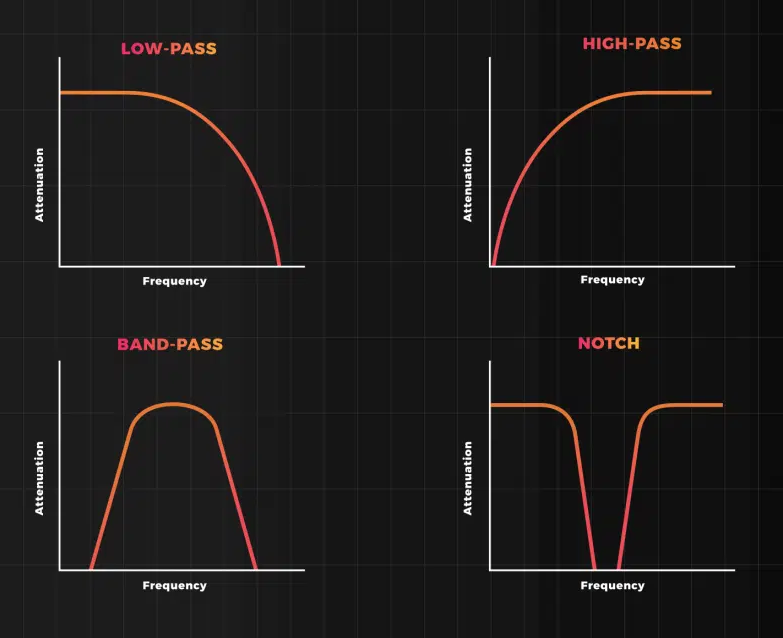

In [29]:
# Create a copy so we can compare before/after
raw_filtered = raw.copy()

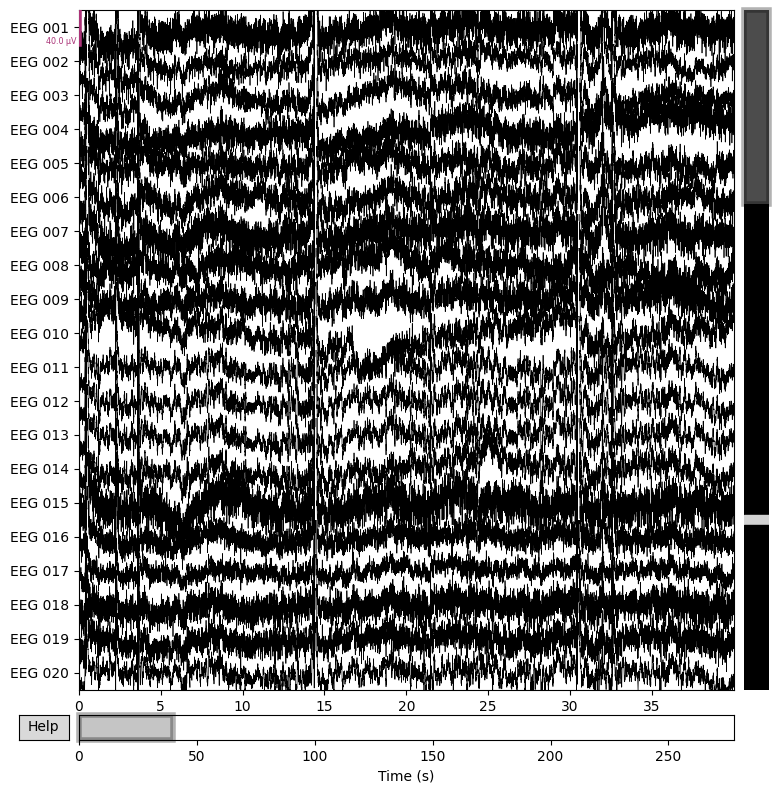

In [30]:
# Plot 1: Original raw data (first 10 seconds)
raw.plot(duration=40);

In [31]:
# Apply bandpass filter: keep frequencies between 1 and 40 Hz

raw_filtered.filter(l_freq=1.0, h_freq=40.0, picks='eeg');


# Apply notch filter: remove 60 Hz electrical noise (use 50 Hz if in Europe)

raw_filtered.notch_filter(freqs=60, picks='eeg');

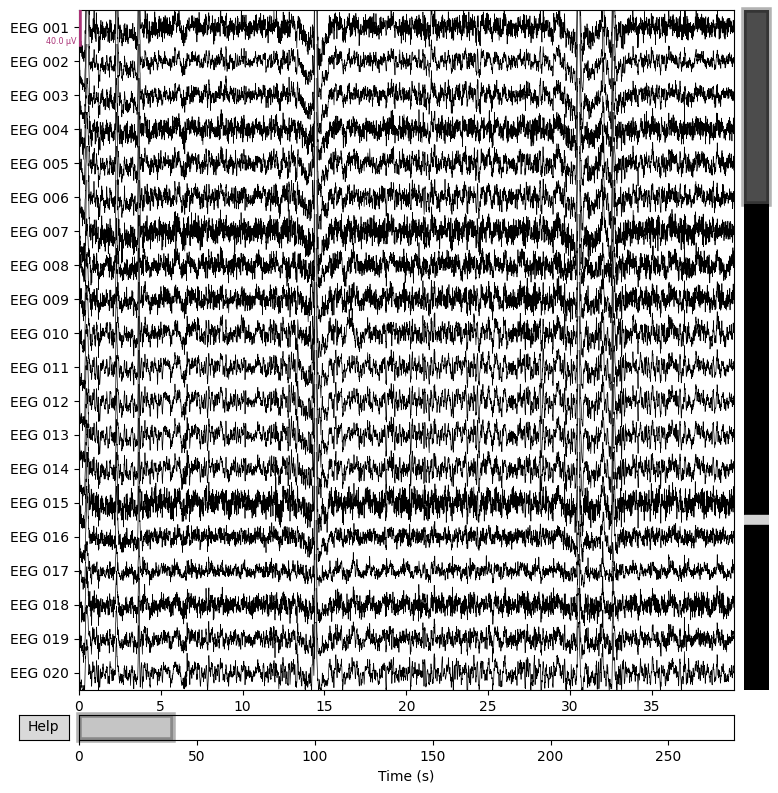

In [32]:
# Plot 2: After filtering
raw_filtered.plot(duration=40);

C:\Users\yucca\AppData\Local\Temp\ipykernel_5892\2079046949.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


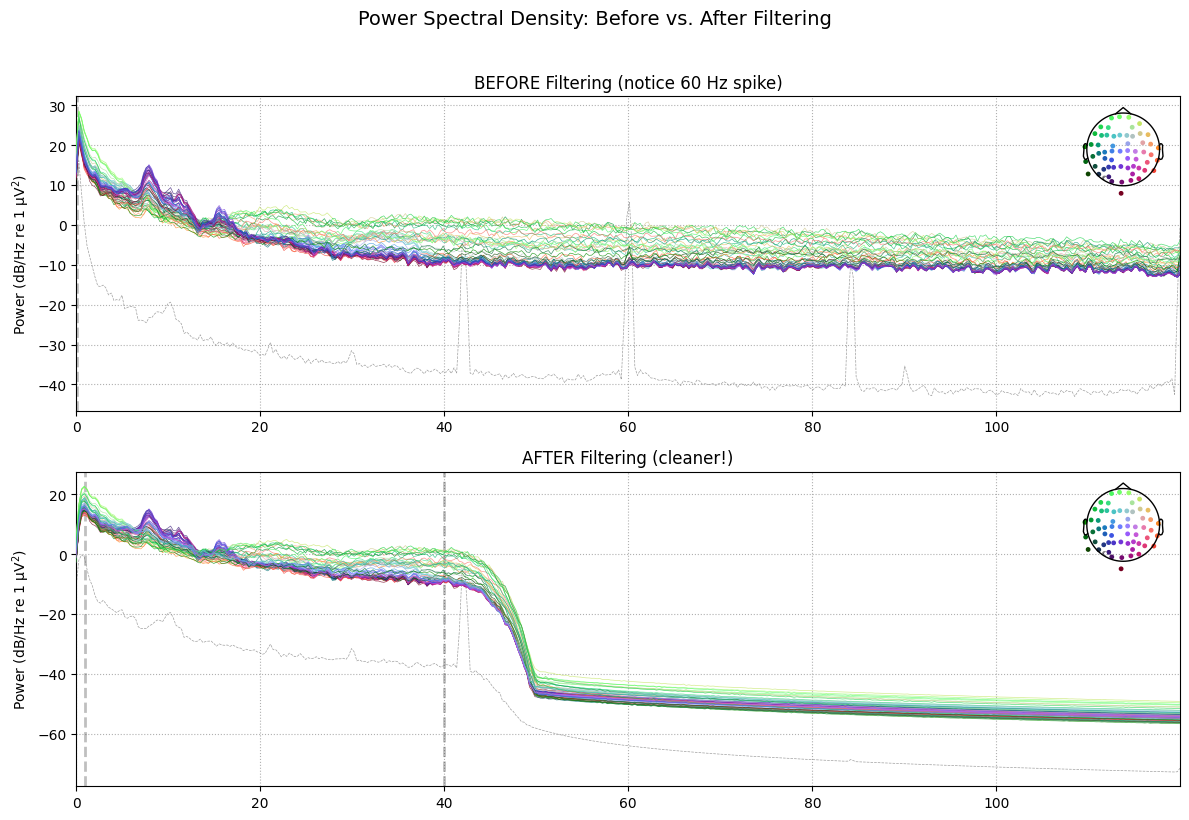

In [33]:
# Compare before and after
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Before filtering
raw.compute_psd(picks='eeg', fmax=120).plot(axes=ax1, show=False)
ax1.set_title('BEFORE Filtering (notice 60 Hz spike)', fontsize=12)
ax1.set_xlabel('')

# After filtering
raw_filtered.compute_psd(picks='eeg', fmax=120).plot(axes=ax2, show=False)
ax2.set_title('AFTER Filtering (cleaner!)', fontsize=12)

plt.suptitle('Power Spectral Density: Before vs. After Filtering', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## **Step 5:** Set Reference (Re-referencing)
 
 EEG measures **differences** in voltage between electrodes. We need a reference point.
 The most common approach is "average reference" - compare each electrode to the 
 average of all electrodes.

In [34]:
print("🔧 Applying average reference...")
raw_filtered.set_eeg_reference('average', projection=True)
raw_filtered.apply_proj()
print("✅ Average reference applied!")

🔧 Applying average reference...
✅ Average reference applied!


## **Step 6:** Detect Bad Channels
 
 Sometimes electrodes don't work well (poor contact, broken wire, etc.).
 We'll automatically detect "bad" channels by looking for:
 - Channels that are too flat (no signal)
 - Channels with unusual variance (too noisy or too quiet)

In [35]:
raw_filtered

<Raw | sample_audvis_raw.fif, 70 x 166800 (277.7 s), ~92.0 MiB, data loaded>

🔍 Detecting bad channels...


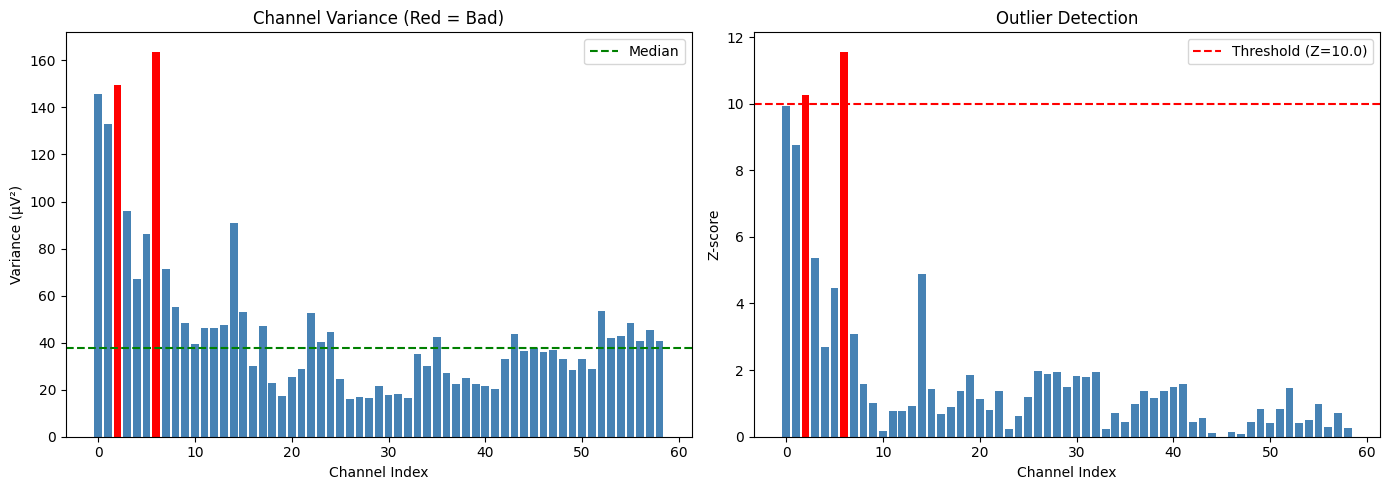

⚠️  Found 2 bad channels: ['EEG 003', 'EEG 007']


In [36]:
# Let's see what we have
def detect_bad_channels(raw, z_threshold=4.5):
    """
    Detect bad EEG channels using statistical methods.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        The EEG data
    z_threshold : float
        How many standard deviations away is "bad" (default: 3.5)
    
    Returns:
    --------
    bad_channels : list
        Names of channels to mark as bad
    """
    # Get EEG data
    eeg_picks = mne.pick_types(raw.info, meg=False, eeg=True)
    eeg_data = raw.get_data(picks=eeg_picks) * 1e6  # Convert to microvolts
    eeg_channels = [raw.ch_names[i] for i in eeg_picks]
    
    # Calculate variance for each channel
    variances = np.var(eeg_data, axis=1)
    
    # Use median absolute deviation (more robust than standard deviation)
    mad = stats.median_abs_deviation(variances)
    median_var = np.median(variances)
    
    # Calculate z-scores
    z_scores = np.abs((variances - median_var) / (mad + 1e-10))
    
    # Find outliers
    bad_indices = np.where(z_scores > z_threshold)[0]
    bad_channels = [eeg_channels[i] for i in bad_indices]
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Variance per channel
    colors = ['red' if ch in bad_channels else 'steelblue' for ch in eeg_channels]
    ax1.bar(range(len(eeg_channels)), variances, color=colors)
    ax1.set_xlabel('Channel Index')
    ax1.set_ylabel('Variance (µV²)')
    ax1.set_title('Channel Variance (Red = Bad)')
    ax1.axhline(median_var, color='green', linestyle='--', label='Median')
    ax1.legend()
    
    # Plot 2: Z-scores
    ax2.bar(range(len(eeg_channels)), z_scores, color=colors)
    ax2.axhline(z_threshold, color='red', linestyle='--', label=f'Threshold (Z={z_threshold})')
    ax2.set_xlabel('Channel Index')
    ax2.set_ylabel('Z-score')
    ax2.set_title('Outlier Detection')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return bad_channels

# Detect bad channels
print("🔍 Detecting bad channels...")
bad_chans = detect_bad_channels(raw_filtered, z_threshold=10.0)

if bad_chans:
    print(f"⚠️  Found {len(bad_chans)} bad channels: {bad_chans}")
    # raw_filtered.info['bads'] = bad_chans
    
    # Interpolate (estimate what the signal should be from neighbors)
    # print("🔧 Interpolating bad channels...")
    # raw_filtered.interpolate_bads()
    # print("✅ Bad channels interpolated!")
else:
    print("✅ No bad channels detected - data looks good!")

## **Step 7:** Independent Component Analysis (ICA)
 
 This is the clever part! ICA separates EEG into independent "sources":
 - Brain activity
 - Eye blinks
 - Eye movements
 - Heartbeat
 - Muscle activity



Starting ICA - This may take a minute...
✅ ICA found 19 components!


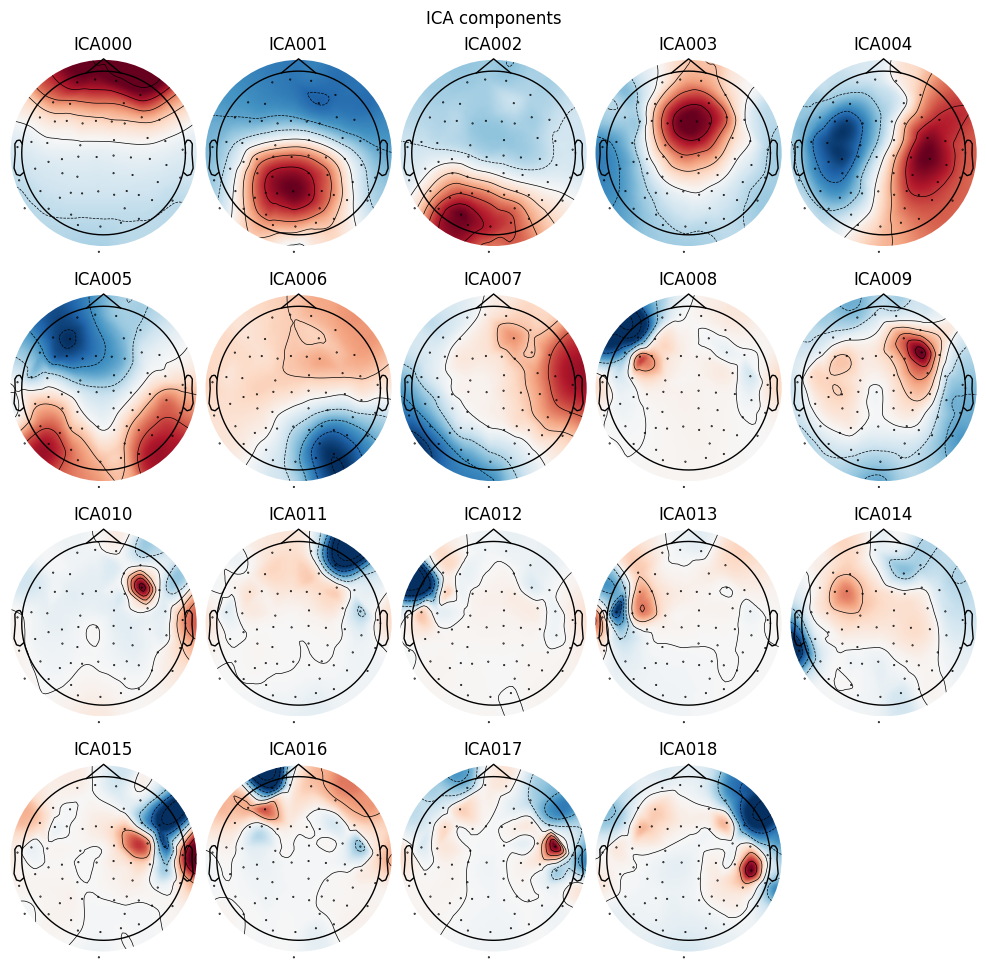

<Figure size 1200x600 with 0 Axes>

In [37]:
print("\n" + "="*60)
print("Starting ICA - This may take a minute...")
print("="*60)

# Create ICA object
# n_components: how many sources to find (0.95 = 95% of variance explained)
ica = mne.preprocessing.ICA(
    n_components=0.95,
    random_state=42,  # For reproducibility
    method='infomax',  # A popular ICA algorithm
    fit_params=dict(extended=True)
)

# Fit ICA to the data
ica.fit(raw_filtered)
print(f"✅ ICA found {ica.n_components_} components!")

# Visualize the components
# Each "component" is a separate source of signal
fig = ica.plot_components(inst=raw_filtered, picks=range(0, min(20, ica.n_components_)))
plt.suptitle('ICA Components (Topographic Maps)\nLook for symmetric frontal patterns (eyes) or concentrated spots', 
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Step 8: Automatically Detect Artifacts
 
 MNE can automatically find components that match known artifacts:
 - **Eye blinks**: Use EOG channels
 - **Heartbeat**: Use ECG channel (if available)


🔍 Detecting eye blink components...
   Found components matching eye blinks: [np.int64(0)]


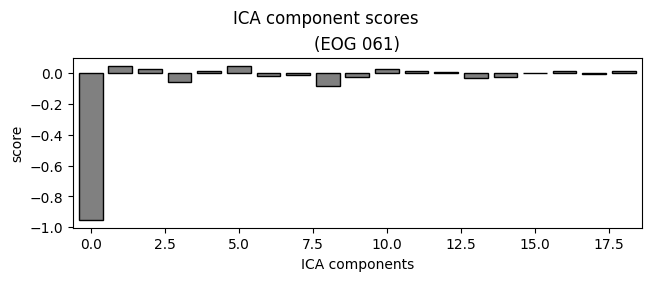

<Figure size 1200x600 with 0 Axes>

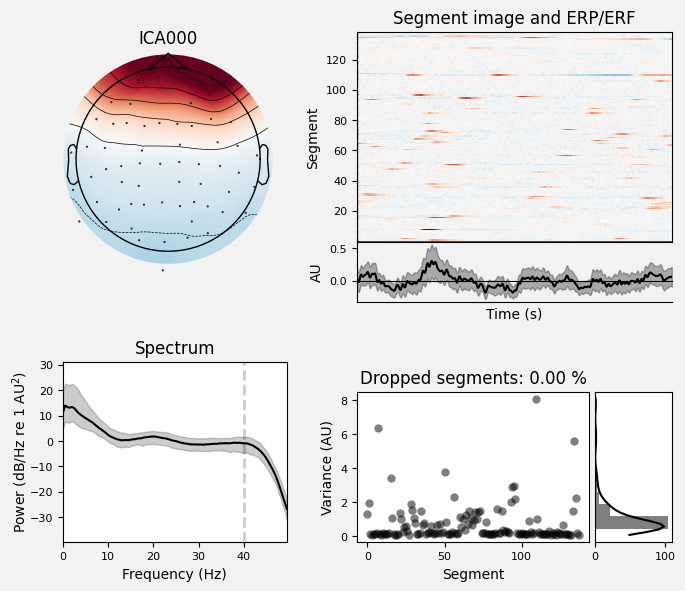


✅ Marked 1 components for removal


In [38]:
# Find eye blink components
print("\n🔍 Detecting eye blink components...")
eog_indices, eog_scores = ica.find_bads_eog(raw_filtered, ch_name='EOG 061')
print(f"   Found components matching eye blinks: {eog_indices}")

# Visualize the detection
if eog_indices:
    fig = ica.plot_scores(eog_scores, labels='EOG 061')
    plt.suptitle('Eye Blink Detection Scores\n(Higher = more likely to be eye blinks)', 
                 y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Show what these components look like
    fig = ica.plot_properties(raw_filtered, picks=eog_indices[:2], psd_args={'fmax': 50})
    plt.show()

# Mark these components for removal
ica.exclude = eog_indices
print(f"\n✅ Marked {len(ica.exclude)} components for removal")

## **Step 9:** Inspect Specific Components 
 
 Let's look at the first few components in detail to understand what we're seeing.


📊 Detailed view of components [0, 1, 2]:


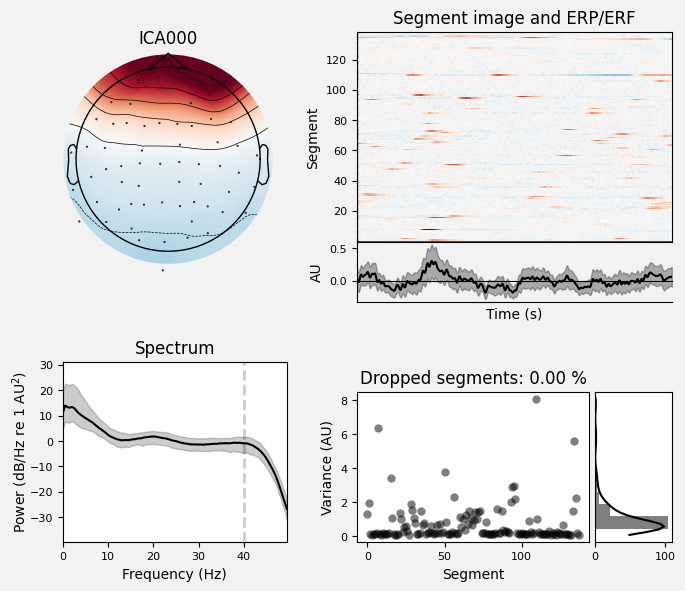

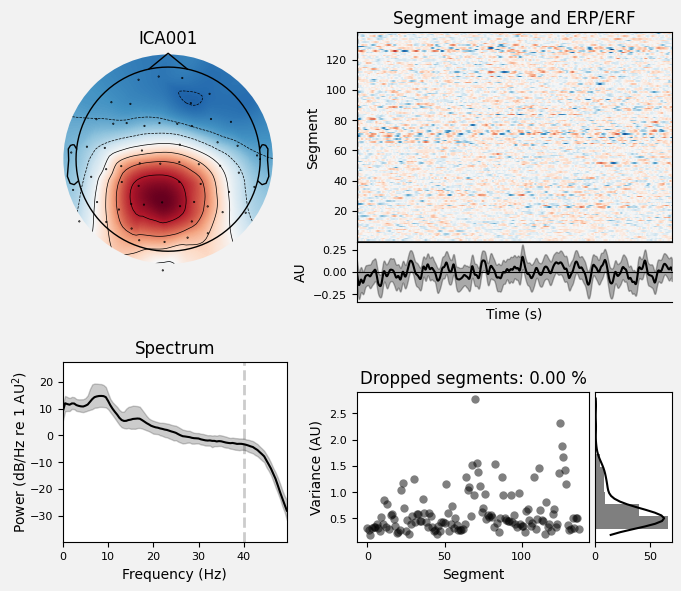

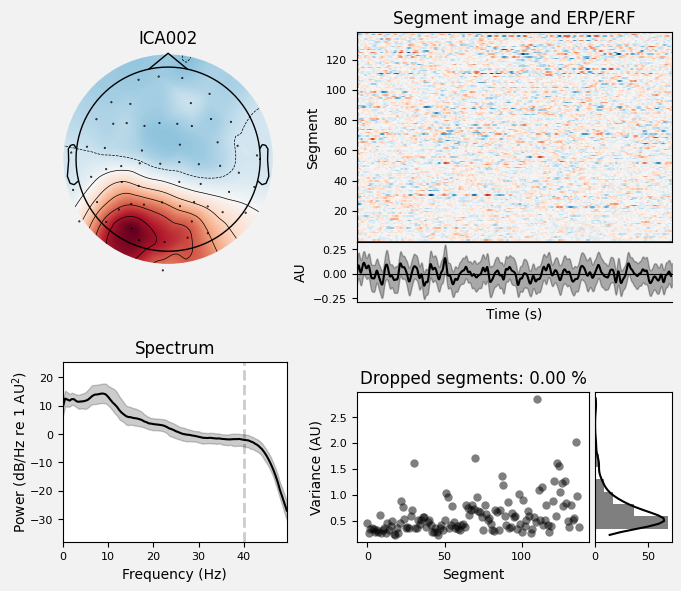


💡 What to look for:
   - Eye blinks: Frontal (forehead) topography, spiky time course
   - Heartbeat: Often on left side, regular rhythm ~60-80 bpm
   - Muscle: High frequency (>20 Hz), temporal or occipital location
   - Brain: Broader spatial distribution, mixed frequencies


In [39]:
# Show properties of first 3 components
components_to_check = list(range(min(3, ica.n_components_)))
print(f"\n📊 Detailed view of components {components_to_check}:")

fig = ica.plot_properties(raw_filtered, picks=components_to_check, psd_args={'fmax': 50})
plt.show()

print("\n💡 What to look for:")
print("   - Eye blinks: Frontal (forehead) topography, spiky time course")
print("   - Heartbeat: Often on left side, regular rhythm ~60-80 bpm")
print("   - Muscle: High frequency (>20 Hz), temporal or occipital location")
print("   - Brain: Broader spatial distribution, mixed frequencies")

## **Step 10:** Apply ICA Cleaning

Now we'll remove the artifact components and see the cleaned result!


🔧 Applying ICA to remove artifacts...


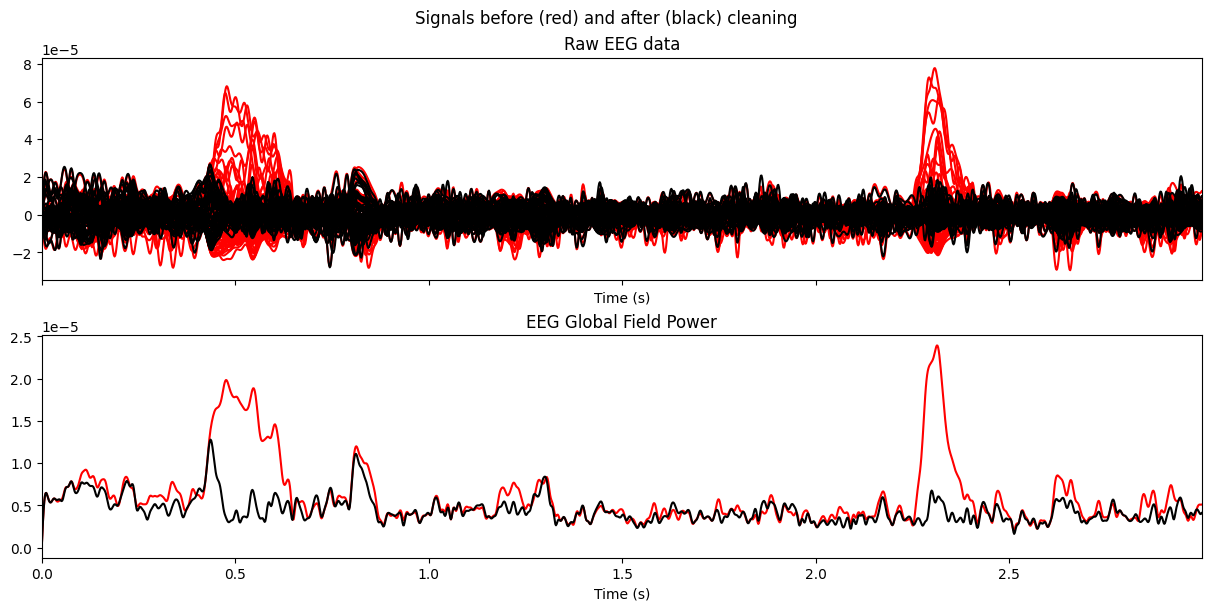

<Figure size 1200x600 with 0 Axes>

✅ ICA cleaning complete!


In [40]:

print("\n🔧 Applying ICA to remove artifacts...")

# Create overlay plot to see before/after
fig = ica.plot_overlay(raw_filtered, exclude=ica.exclude, picks='eeg')
plt.suptitle('ICA Cleaning Overlay\nRed = Original | Black = Cleaned', y=1.02, fontsize=12)
plt.show()

# Apply the cleaning
raw_cleaned = ica.apply(raw_filtered.copy())
print("✅ ICA cleaning complete!")

## **Step 11:** Compare Final Results
 
 Let's see how much we improved the data quality!

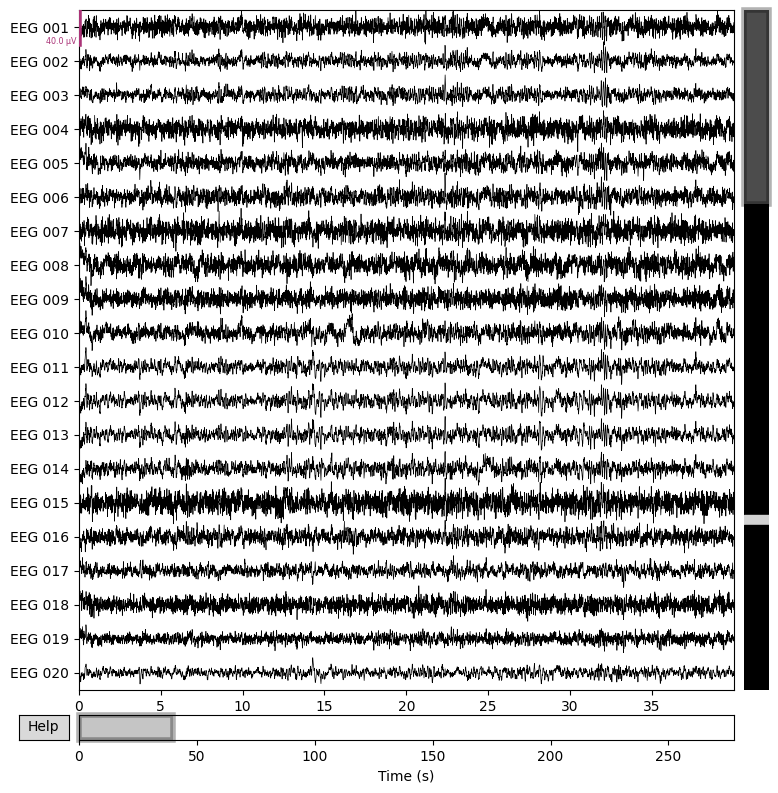

In [41]:
# Plot 3: After ICA cleaning
raw_cleaned.plot(duration=40);

C:\Users\yucca\AppData\Roaming\Python\Python313\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


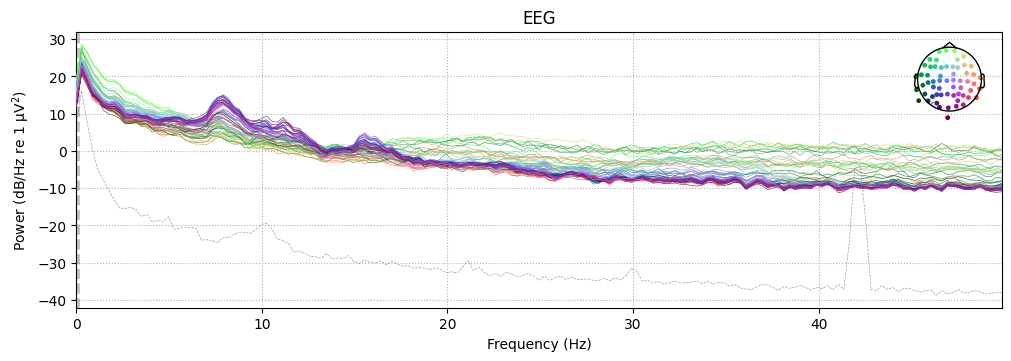

In [45]:
# Before filtering
raw.compute_psd(fmax=50, picks='eeg').plot();

C:\Users\yucca\AppData\Roaming\Python\Python313\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


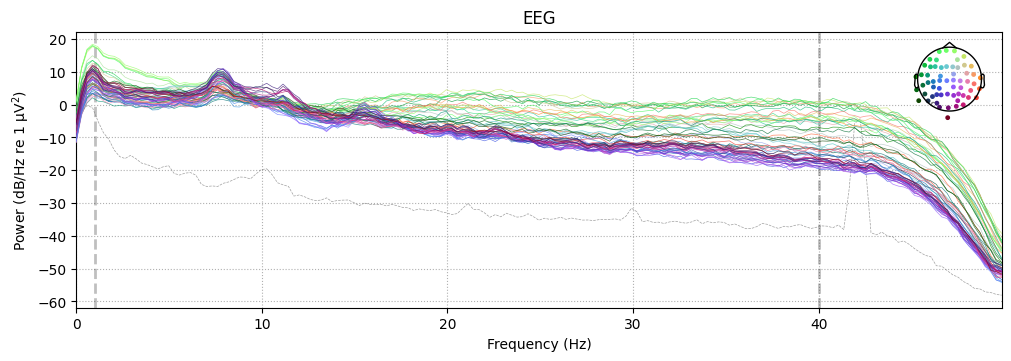

In [42]:
# Before cleaning
raw_filtered.compute_psd(fmax=50, picks='eeg').plot();

C:\Users\yucca\AppData\Roaming\Python\Python313\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


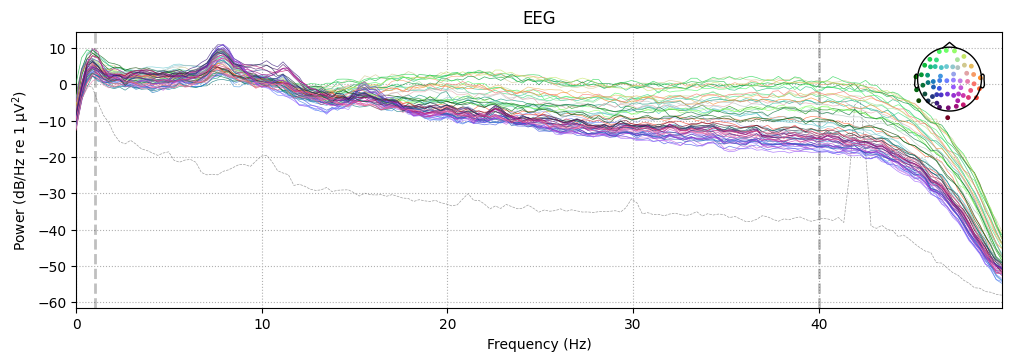

In [43]:
# After cleaning
raw_cleaned.compute_psd(fmax=50, picks='eeg').plot();

## **Step 12:** Save the Cleaned Data
 
 Now that we have clean data, we can save it for further analysis!

In [55]:
# Create output directory
output_dir = 'eeg_tutorial_output'
os.makedirs(output_dir, exist_ok=True)

# Save the cleaned data
output_file = os.path.join(output_dir, 'sample_cleaned_raw.fif')
raw_cleaned.save(output_file, overwrite=True)

print(f"\n💾 Cleaned data saved to: {output_file}")
print(f"   Duration: {raw_cleaned.times[-1]:.1f} seconds")
print(f"   Channels: {len(raw_cleaned.ch_names)}")
print(f"   Sampling rate: {raw_cleaned.info['sfreq']} Hz") 


💾 Cleaned data saved to: eeg_tutorial_output\sample_cleaned_raw.fif
   Duration: 277.7 seconds
   Channels: 70
   Sampling rate: 600.614990234375 Hz


## **Summary:** What We Learned
 
 Congratulations! You've completed a full EEG preprocessing pipeline:
 
 1. ✅ **Loaded** real EEG data
 2. ✅ **Visualized** raw signals and power spectra
 3. ✅ **Filtered** the data (bandpass + notch filters)
 4. ✅ **Re-referenced** to average reference
 5. ✅ **Detected** and interpolated bad channels
 6. ✅ **Applied ICA** to separate signal sources
 7. ✅ **Removed** eye and muscle artifacts
 8. ✅ **Saved** clean data for analysis
 
### Next Steps:
 - **Epoching**: Cut the continuous data into trials/events
 - **Evoked Responses**: Average across trials to see brain responses
 - **Time-Frequency Analysis**: See how brain rhythms change over time
 - **Source Localization**: Estimate where in the brain signals come from
 
### Key Concepts to Remember:
 - EEG signals are **tiny** (microvolts) and **noisy**
 - **Filtering** removes unwanted frequencies
 - **ICA** separates mixed signals into independent sources
 - Always **visualize** your data at each step!
 
 ### Tips for Your Own Data:
 1. Always plot your data before and after each processing step
 2. Save intermediate results so you can go back if needed
 3. Document what parameters you used (filters, thresholds, etc.)
 4. When in doubt, be conservative - it's better to keep questionable data than remove good data
